In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import MinMaxScaler

import warnings 
warnings.filterwarnings('ignore')

plt.style.use('ggplot')


In [3]:
df = pd.read_csv('Nassau Candy Distributor (2).csv')

In [4]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [5]:
df.shape

(10194, 18)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  int64  
 6   Country/Region  10194 non-null  object 
 7   City            10194 non-null  object 
 8   State/Province  10194 non-null  object 
 9   Postal Code     10194 non-null  object 
 10  Division        10194 non-null  object 
 11  Region          10194 non-null  object 
 12  Product ID      10194 non-null  object 
 13  Product Name    10194 non-null  object 
 14  Sales           10194 non-null  float64
 15  Units           10194 non-null  int64  
 16  Gross Profit    10194 non-null  float64
 17  Cost            10194 non-null 

In [7]:
df.describe()

,Row ID,Customer ID,Sales,Units,Gross Profit,Cost
count,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,134468.961154,13.908537,3.791838,9.166451,4.742087
std,2942.898656,20231.483007,11.341020,2.228317,6.643740,5.061647
min,1.000000,100006.000000,1.250000,1.000000,0.250000,0.600000
25%,2549.250000,117212.000000,7.200000,2.000000,4.900000,2.400000
50%,5097.500000,133550.000000,10.800000,3.000000,7.470000,3.600000
75%,7645.750000,152051.000000,18.000000,5.000000,12.250000,5.700000
max,10194.000000,192314.000000,260.000000,14.000000,130.000000,130.000000


In [8]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Division          0
Region            0
Product ID        0
Product Name      0
Sales             0
Units             0
Gross Profit      0
Cost              0
dtype: int64

In [9]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

In [10]:
df['Lead_Time'] = (df['Ship Date'] - df['Order Date']).dt.days

In [11]:
df[['Lead_Time','Order Date','Ship Date']].head()

,Lead_Time,Order Date,Ship Date
0,909,2024-01-03,2026-06-30
1,909,2024-01-04,2026-07-01
2,909,2024-01-04,2026-07-01
3,909,2024-01-04,2026-07-01
4,912,2024-01-05,2026-07-05


In [12]:
df = df[df['Lead_Time'] >= 0]


In [13]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost,Lead_Time
0,1,US-2021-103800-CHO-MIL-31000,2024-01-03,2026-06-30,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28,909
1,2,US-2021-112326-CHO-TRI-54000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60,909
2,3,US-2021-112326-CHO-NUT-13000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00,909
3,4,US-2021-112326-CHO-SCR-58000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30,909
4,5,US-2021-141817-CHO-TRI-54000,2024-01-05,2026-07-05,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90,912


In [14]:
df.shape

(10194, 19)

In [15]:
factory_map = {
"Wonka Bar - Nutty Crunch Surprise":"Lot's O' Nuts",
"Wonka Bar - Fudge Mallows":"Lot's O' Nuts",
"Wonka Bar - Scrumdiddlyumptious":"Lot's O' Nuts",
"Wonka Bar - Milk Chocolate":"Wicked Choccy's",
"Wonka Bar - Triple Dazzle Caramel":"Wicked Choccy's",
"Laffy Taffy":"Sugar Shack",
"SweeTARTS":"Sugar Shack",
"Nerds":"Sugar Shack",
"Fun Dip":"Sugar Shack",
"Fizzy Lifting Drinks":"Sugar Shack",
"Everlasting Gobstopper":"Secret Factory",
"Lickable Wallpaper":"Secret Factory",
"Wonka Gum":"Secret Factory",    
"Hair Toffee":"The Other Factory",
"Kazookles":"The Other Factory"    
}

In [16]:
df['Factory'] = df['Product Name'].map(factory_map)
df[['Product Name','Factory']].head()

,Product Name,Factory
0,Wonka Bar - Milk Chocolate,Wicked Choccy's
1,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's
2,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts
3,Wonka Bar -Scrumdiddlyumptious,NaN
4,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's


In [17]:
df['Route'] = df['Factory'] + " → " + df['State/Province']

In [18]:
df['Route'].head()

0           Wicked Choccy's → Texas
1        Wicked Choccy's → Illinois
2          Lot's O' Nuts → Illinois
3                               NaN
4    Wicked Choccy's → Pennsylvania
Name: Route, dtype: object

In [19]:
df['Delayed'] = np.where(df['Lead_Time'] > 5, 1, 0)

In [20]:
df['Delayed'].head()

0    1
1    1
2    1
3    1
4    1
Name: Delayed, dtype: int64

In [21]:
df['Delayed'].shape

(10194,)

In [22]:
avg_lead = df['Lead_Time'].mean()

In [23]:
print(avg_lead)

1320.8418677653522


In [24]:
print(type(avg_lead))

<class 'numpy.float64'>


In [25]:
print("Average Lead Time =",round(avg_lead,2),"Days")

Average Lead Time = 1320.84 Days


In [26]:
delay_frequency = df['Delayed'].mean()*100

In [27]:
print("Delay Frequency =",round(delay_frequency,2),"%")

Delay Frequency = 100.0 %


In [28]:
print("Total_Orders =",df['Order ID'].nunique())

Total_Orders = 8549


In [29]:
route_analysis = df.groupby('Route').agg(
    Total_Shipments=('Order ID','count')
)

route_analysis

,Total_Shipments
Route,
Lot's O' Nuts → Alabama,22
Lot's O' Nuts → Alberta,4
Lot's O' Nuts → Arizona,61
Lot's O' Nuts → Arkansas,21
Lot's O' Nuts → British Columbia,16
...,...
Wicked Choccy's → Vermont,5
Wicked Choccy's → Virginia,106
Wicked Choccy's → Washington,221


In [30]:
route_analysis = df.groupby('Route').agg(
    Avg_Lead_Time=('Lead_Time','mean')
)

route_analysis

,Avg_Lead_Time
Route,
Lot's O' Nuts → Alabama,1223.818182
Lot's O' Nuts → Alberta,1273.750000
Lot's O' Nuts → Arizona,1279.344262
Lot's O' Nuts → Arkansas,1290.904762
Lot's O' Nuts → British Columbia,1273.812500
...,...
Wicked Choccy's → Vermont,1418.600000
Wicked Choccy's → Virginia,1238.877358
Wicked Choccy's → Washington,1375.723982


In [31]:
route_analysis = df.groupby('Route').agg(
    Lead_Time_Std=('Lead_Time','std')
)

route_analysis

,Lead_Time_Std
Route,
Lot's O' Nuts → Alabama,233.368835
Lot's O' Nuts → Alberta,298.430757
Lot's O' Nuts → Arizona,262.916583
Lot's O' Nuts → Arkansas,293.585406
Lot's O' Nuts → British Columbia,298.431057
...,...
Wicked Choccy's → Vermont,200.285546
Wicked Choccy's → Virginia,254.774025
Wicked Choccy's → Washington,270.802982


In [32]:
route_analysis = df.groupby('Route').agg(
    Shipments=('Order ID','count'),
    Avg_Lead_Time=('Lead_Time','mean'),
    Lead_Time_STD=('Lead_Time','std')
)

route_analysis.head()

,Shipments,Avg_Lead_Time,Lead_Time_STD
Route,,,
Lot's O' Nuts → Alabama,22,1223.818182,233.368835
Lot's O' Nuts → Alberta,4,1273.750000,298.430757
Lot's O' Nuts → Arizona,61,1279.344262,262.916583
Lot's O' Nuts → Arkansas,21,1290.904762,293.585406
Lot's O' Nuts → British Columbia,16,1273.812500,298.431057


In [33]:
Top10 = route_analysis.sort_values(
    by='Avg_Lead_Time'
).head(10)

Top10

,Shipments,Avg_Lead_Time,Lead_Time_STD
Route,,,
Secret Factory → Nebraska,1,906.0,NaN
Secret Factory → New Mexico,2,906.0,2.828427
The Other Factory → Louisiana,1,907.0,NaN
The Other Factory → Connecticut,2,907.5,2.121320
Secret Factory → Mississippi,1,908.0,NaN
Wicked Choccy's → Maine,2,908.0,0.000000
Secret Factory → Louisiana,2,908.5,0.707107
Secret Factory → Delaware,1,909.0,NaN
Secret Factory → South Carolina,1,909.0,NaN


In [34]:
Bottom10 = route_analysis.sort_values(
    by='Avg_Lead_Time',
    ascending=False
).head(10)

Bottom10

,Shipments,Avg_Lead_Time,Lead_Time_STD
Route,,,
Sugar Shack → New Jersey,1,1642.000000,NaN
Sugar Shack → Connecticut,1,1641.000000,NaN
Secret Factory → New Hampshire,1,1641.000000,NaN
Wicked Choccy's → West Virginia,2,1639.000000,0.000000
Lot's O' Nuts → West Virginia,1,1639.000000,NaN
Lot's O' Nuts → Vermont,3,1638.666667,1.154701
The Other Factory → Nevada,1,1638.000000,NaN
Sugar Shack → California,1,1638.000000,NaN
Secret Factory → Connecticut,1,1638.000000,NaN


In [35]:
scaler = MinMaxScaler()

df['Efficiency_Score'] = 100 - (
    scaler.fit_transform(df[['Lead_Time']])*100
)

In [36]:
df['Efficiency_Score']

0        99.322493
1        99.322493
2        99.322493
3        99.322493
4        98.915989
           ...    
10189     0.406504
10190     0.406504
10191     0.406504
10192     0.406504
10193     0.406504
Name: Efficiency_Score, Length: 10194, dtype: float64

In [37]:
Region_Analysis = df.groupby('Region').agg(
    Shipments=('Order ID','count'),
    Avg_Lead_Time=('Lead_Time','mean')
)

Region_Analysis

,Shipments,Avg_Lead_Time
Region,,
Atlantic,2986,1322.745144
Gulf,1620,1311.374691
Interior,2335,1323.091221
Pacific,3253,1322.194897


In [38]:
State_Analysis = df.groupby('State/Province').agg(
    Shipments=('Order ID','count'),
    Avg_Lead_Time=('Lead_Time','mean')
)

State_Analysis.head()

,Shipments,Avg_Lead_Time
State/Province,,
Alabama,61,1291.278689
Alberta,26,1274.076923
Arizona,224,1309.214286
Arkansas,60,1285.733333
British Columbia,22,1290.318182


In [39]:
Ship_Mode = df.groupby('Ship Mode').agg(
    Orders=('Order ID','count'),
    Avg_Lead_Time=('Lead_Time','mean'),
    Avg_Cost=('Cost','mean'),
    Avg_Profit=('Gross Profit','mean')
)

Ship_Mode

,Orders,Avg_Lead_Time,Avg_Cost,Avg_Profit
Ship Mode,,,,
First Class,1548,1338.275840,4.721124,9.051092
Same Day,547,1333.442413,4.411225,8.593656
Second Class,1979,1323.845376,4.827539,9.250389
Standard Class,6120,1314.334641,4.749328,9.219683


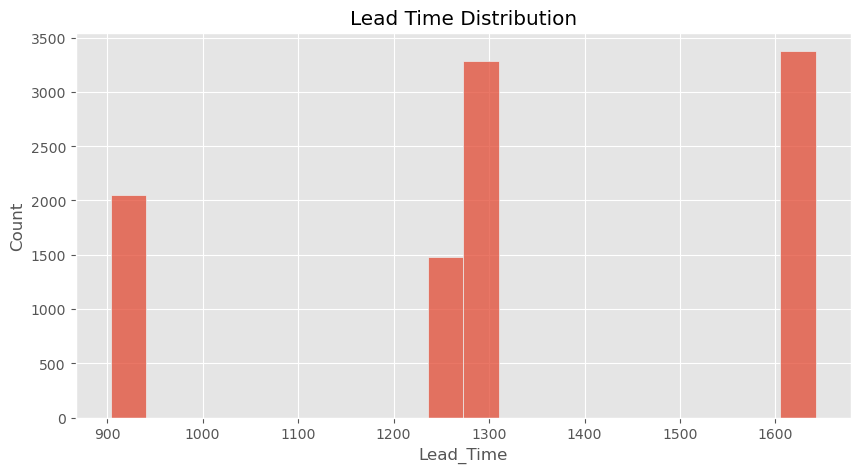

In [40]:
plt.figure(figsize=(10,5))

sns.histplot(df['Lead_Time'], bins=20)

plt.title('Lead Time Distribution')
plt.show()

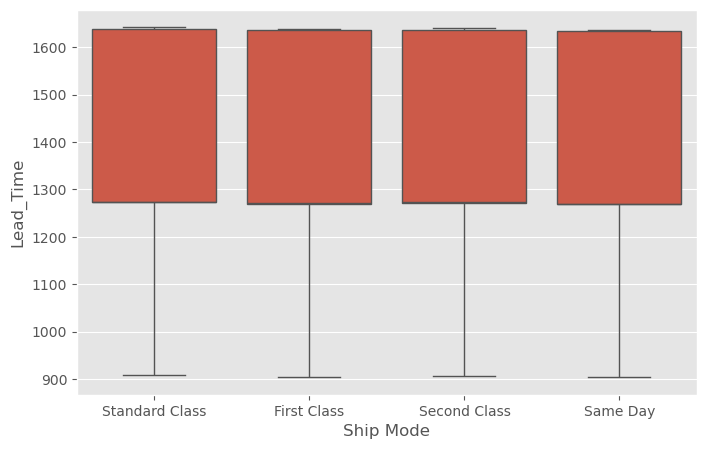

In [41]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Ship Mode',
    y='Lead_Time',
    data = df
)

plt.show()

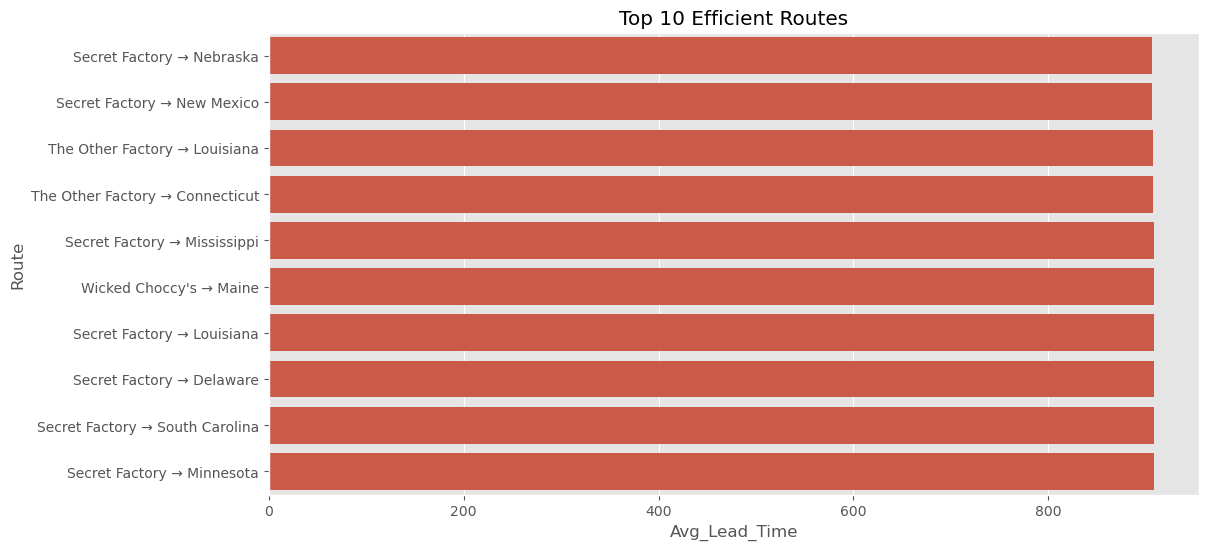

In [43]:
Top10.reset_index(inplace=True)

plt.figure(figsize=(12,6))

sns.barplot(
    x='Avg_Lead_Time',
    y='Route',
    data=Top10
)

plt.title("Top 10 Efficient Routes")

plt.show()

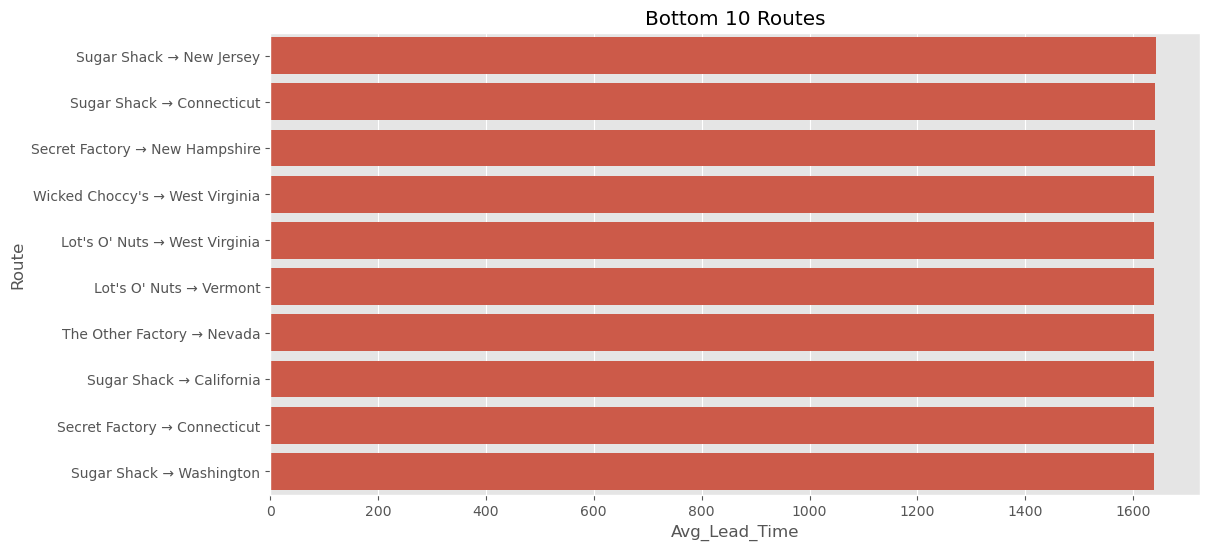

In [44]:
Bottom10.reset_index(inplace=True)

plt.figure(figsize=(12,6))

sns.barplot(
    x='Avg_Lead_Time',
    y='Route',
    data=Bottom10
)

plt.title("Bottom 10 Routes")

plt.show()

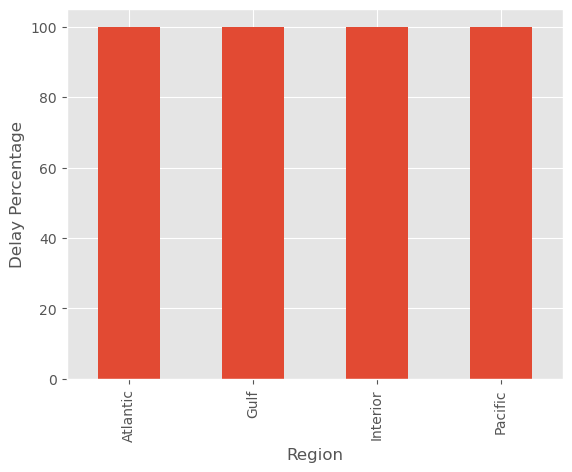

In [45]:
delay_region = df.groupby('Region')['Delayed'].mean()*100

delay_region.plot(kind='bar')

plt.ylabel('Delay Percentage')

plt.show()

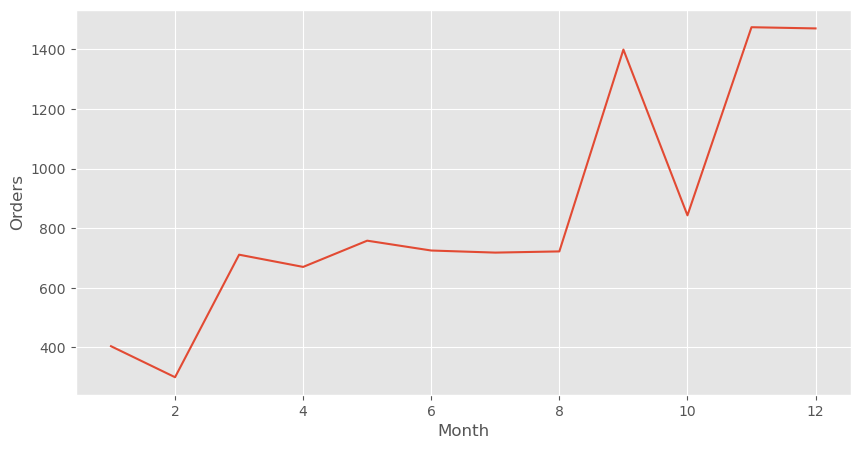

In [46]:
df['Month'] = df['Order Date'].dt.month

monthly = df.groupby('Month')['Order ID'].count()

monthly.plot(figsize=(10,5))

plt.ylabel('Orders')

plt.show()

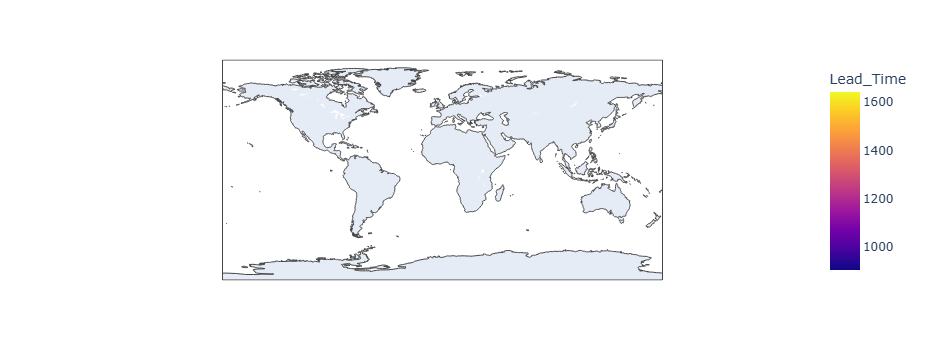

In [47]:
fig = px.scatter_geo(
    df,
    locations='State/Province',
    locationmode='USA-states',
    color='Lead_Time',
    size='Units',
    hover_name='State/Province'
)

fig.show()

In [48]:
kpi = pd.DataFrame({

'Metric':[
'Total Orders',
'Average Lead Time',
'Delay Frequency'
],

'Value':[
df['Order ID'].nunique(),
round(df['Lead_Time'].mean(),2),
round(delay_frequency,2)
]

})

kpi

,Metric,Value
0,Total Orders,8549.00
1,Average Lead Time,1320.84
2,Delay Frequency,100.00


In [51]:
import streamlit as st
import pandas as pd
import plotly.express as px
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# ---------------------------------------
# Page Configuration
# ---------------------------------------
st.set_page_config(
    page_title="Nassau Candy Shipping Dashboard",
    layout="wide"
)

st.title("🚚 Factory-to-Customer Shipping Route Efficiency Analysis")

# ---------------------------------------
# Load Dataset
# ---------------------------------------
df = pd.read_csv("Nassau Candy Distributor (2).csv")

# ---------------------------------------
# Date Conversion
# ---------------------------------------
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)
# ---------------------------------------
# Lead Time
# ---------------------------------------
df['Lead_Time'] = (df['Ship Date'] - df['Order Date']).dt.days

df = df[df['Lead_Time'] >= 0]

# ---------------------------------------
# Product → Factory Mapping
# ---------------------------------------
factory_map = {

"Wonka Bar - Nutty Crunch Surprise":"Lot's O' Nuts",
"Wonka Bar - Fudge Mallows":"Lot's O' Nuts",
"Wonka Bar -Scrumdiddlyumptious":"Lot's O' Nuts",

"Wonka Bar - Milk Chocolate":"Wicked Choccy's",
"Wonka Bar - Triple Dazzle Caramel":"Wicked Choccy's",

"Laffy Taffy":"Sugar Shack",
"SweeTARTS":"Sugar Shack",
"Nerds":"Sugar Shack",
"Fun Dip":"Sugar Shack",
"Fizzy Lifting Drinks":"Sugar Shack",

"Everlasting Gobstopper":"Secret Factory",
"Lickable Wallpaper":"Secret Factory",
"Wonka Gum":"Secret Factory",

"Hair Toffee":"The Other Factory",
"Kazookles":"The Other Factory"
}

# ---------------------------------------
# Factory Column
# ---------------------------------------
df['Factory'] = df['Product Name'].map(factory_map)

# Route
df['Route'] = df['Factory'] + " → " + df['State/Province']

# ---------------------------------------
# Sidebar Filters
# ---------------------------------------
st.sidebar.header("Filters")

start_date, end_date = st.sidebar.date_input(
    "Date Range",
    [df['Order Date'].min(), df['Order Date'].max()]
)

selected_region = st.sidebar.multiselect(
    "Region",
    options=df['Region'].unique(),
    default=df['Region'].unique()
)

selected_state = st.sidebar.multiselect(
    "State",
    options=df['State/Province'].unique(),
    default=df['State/Province'].unique()
)

selected_shipmode = st.sidebar.multiselect(
    "Ship Mode",
    options=df['Ship Mode'].unique(),
    default=df['Ship Mode'].unique()
)

threshold = st.sidebar.slider(
    "Delay Threshold (Days)",
    min_value=1,
    max_value=15,
    value=5
)

# ---------------------------------------
# Filter Data
# ---------------------------------------
filtered_df = df[
    (df['Order Date'] >= pd.to_datetime(start_date)) &
    (df['Order Date'] <= pd.to_datetime(end_date)) &
    (df['Region'].isin(selected_region)) &
    (df['State/Province'].isin(selected_state)) &
    (df['Ship Mode'].isin(selected_shipmode))
]

# ---------------------------------------
# Sidebar Menu
# ---------------------------------------
menu = st.sidebar.radio(
    "Dashboard",
    [
        "Route Efficiency Overview",
        "Geographic Shipping Map",
        "Ship Mode Comparison",
        "Route Drill-Down"
    ]
)

# =====================================================
# 1. ROUTE EFFICIENCY OVERVIEW
# =====================================================
if menu == "Route Efficiency Overview":

    st.header("Route Efficiency Overview")

    col1, col2, col3 = st.columns(3)

    with col1:
        st.metric(
            "Average Lead Time",
            round(filtered_df['Lead_Time'].mean(),2)
        )

    with col2:
        st.metric(
            "Total Orders",
            filtered_df['Order ID'].nunique()
        )

    with col3:
        delay_freq = (filtered_df['Lead_Time'] > threshold).mean()*100

        st.metric(
            "Delay Frequency %",
            round(delay_freq,2)
        )

    # Route Analysis
    route_analysis = filtered_df.groupby('Route').agg(
        Total_Shipments=('Order ID','count'),
        Avg_Lead_Time=('Lead_Time','mean'),
        Lead_Time_STD=('Lead_Time','std')
    ).reset_index()

    st.subheader("Top 10 Efficient Routes")

    top10 = route_analysis.sort_values(
        by='Avg_Lead_Time'
    ).head(10)

    fig = px.bar(
        top10,
        x='Avg_Lead_Time',
        y='Route',
        orientation='h',
        color='Avg_Lead_Time'
    )

    st.plotly_chart(fig, use_container_width=True)

# =====================================================
# 2. GEOGRAPHIC SHIPPING MAP
# =====================================================
elif menu == "Geographic Shipping Map":

    st.header("US Shipping Efficiency")

    state_analysis = filtered_df.groupby(
        'State/Province'
    )['Lead_Time'].mean().reset_index()

    fig = px.choropleth(
        state_analysis,
        locations='State/Province',
        locationmode='USA-states',
        color='Lead_Time',
        scope='usa',
        title='Average Lead Time by State'
    )

    st.plotly_chart(fig, use_container_width=True)

    st.subheader("Regional Bottlenecks")

    region_analysis = filtered_df.groupby(
        'Region'
    )['Lead_Time'].mean().reset_index()

    fig2 = px.bar(
        region_analysis,
        x='Region',
        y='Lead_Time',
        color='Lead_Time'
    )

    st.plotly_chart(fig2, use_container_width=True)

# =====================================================
# 3. SHIP MODE COMPARISON
# =====================================================
elif menu == "Ship Mode Comparison":

    st.header("Ship Mode Performance")

    ship_mode = filtered_df.groupby(
        'Ship Mode'
    ).agg(
        Avg_Lead_Time=('Lead_Time','mean'),
        Orders=('Order ID','count')
    ).reset_index()

    fig = px.bar(
        ship_mode,
        x='Ship Mode',
        y='Avg_Lead_Time',
        color='Ship Mode'
    )

    st.plotly_chart(fig, use_container_width=True)

    st.subheader("Lead Time Distribution")

    fig2 = px.box(
        filtered_df,
        x='Ship Mode',
        y='Lead_Time',
        color='Ship Mode'
    )

    st.plotly_chart(fig2, use_container_width=True)

# =====================================================
# 4. ROUTE DRILL-DOWN
# =====================================================
elif menu == "Route Drill-Down":

    st.header("Route Drill-Down")

    state = st.selectbox(
        "Select State",
        filtered_df['State/Province'].unique()
    )

    state_df = filtered_df[
        filtered_df['State/Province'] == state
    ]

    st.subheader("State-Level Insights")

    route_summary = state_df.groupby('Route').agg(
        Shipments=('Order ID','count'),
        Avg_Lead_Time=('Lead_Time','mean')
    ).reset_index()

    st.dataframe(route_summary)

    st.subheader("Order-Level Shipment Timeline")

    fig = px.timeline(
        state_df.head(100),
        x_start='Order Date',
        x_end='Ship Date',
        y='Order ID',
        color='Ship Mode'
    )

    st.plotly_chart(fig, use_container_width=True)

    st.subheader("Order Details")

    st.dataframe(
        state_df[
            ['Order ID',
             'Order Date',
             'Ship Date',
             'Ship Mode',
             'Lead_Time',
             'Sales']
        ]
    )

2026-06-23 12:31:33.025 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-23 12:31:33.027 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-23 12:31:33.029 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-23 12:31:33.030 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-23 12:31:33.214 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-23 12:31:33.215 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-23 12:31:33.216 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-23 12:31:33.224 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [52]:
pwd

'C:\\Users\\Admin'

In [53]:
import os
os.getcwd()

'C:\\Users\\Admin'

In [54]:
import os
print(os.listdir())

['.anaconda', '.conda', '.continuum', '.idlerc', '.ipynb_checkpoints', '.ipython', '.jupyter', '.keras', '.matplotlib', '.ms-ad', '.streamlit', 'anaconda3', 'app.py', 'app.py.txt', 'AppData', 'Application Data', 'BloodDonaPred', 'BloodDonation', 'blood_data', 'Blood_Donation.ipynb', 'Blood_Donations.csv', 'Blood_Donation_Prediction.ipynb', 'Contacts', 'Cookies', 'Desktop', 'Documents', 'Downloads', 'Factory to customer shipping.ipynb', 'Favorites', 'Handwritten Digits.ipynb', 'Handwritten.ipynb', 'IntelGraphicsProfiles', 'leadtime_model.pkl', 'Links', 'Local Settings', 'Microsoft', 'models', 'My Documents', 'Nassau Candy Distributor (1).csv', 'Nassau Candy Distributor (2).csv', 'Nassau Candy Distributor.ipynb', 'Nassau Candy.ipynb', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{7fa2dac1-002e-11f1-81ef-141877c82a1a}.TM.blf', 'NTUSER.DAT{7fa2dac1-002e-11f1-81ef-141877c82a1a}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{7fa2dac1-002e-11f1-81ef-141

In [55]:
!dir

 Volume in drive C has no label.
 Volume Serial Number is D2E0-E488

 Directory of C:\Users\Admin

23-06-2026  12:40    <DIR>          .
02-02-2026  17:50    <DIR>          ..
04-02-2026  18:55    <DIR>          .anaconda
16-06-2026  14:18    <DIR>          .conda
03-02-2026  20:16    <DIR>          .continuum
22-06-2026  20:10    <DIR>          .idlerc
23-06-2026  12:37    <DIR>          .ipynb_checkpoints
03-02-2026  20:17    <DIR>          .ipython
04-02-2026  18:54    <DIR>          .jupyter
04-02-2026  20:41    <DIR>          .keras
03-02-2026  20:25    <DIR>          .matplotlib
11-06-2026  15:49    <DIR>          .ms-ad
16-06-2026  16:53    <DIR>          .streamlit
03-02-2026  20:25    <DIR>          anaconda3
17-06-2026  01:18               329 app.py
23-06-2026  12:40             7,360 app.py.txt
19-02-2026  17:01    <DIR>          BloodDonaPred
19-02-2026  17:03    <DIR>          BloodDonation
17-02-2026  23:52    <DIR>          blood_data
19-02-2026  17:55           218,129

In [56]:
import os

print(os.path.abspath("Factory to customer shipping.ipynb"))

C:\Users\Admin\Factory to customer shipping.ipynb
